In [1]:
import Pkg
Pkg.activate(joinpath(@__DIR__, ".."))
using EccentricBurstTiming, CairoMakie, QuadGK, CSV
using JLD2
# using Unitful, UnitfulAstro
defaulttheme = Theme(Axis = (xgridvisible=false, ygridvisible=false,
                            yminorticks=IntervalsBetween(4),
                            xminorticks=IntervalsBetween(4),
                            yminorticksvisible=true,
                            xminorticksvisible=true,
                            titlefont = :regular,
                            xminorticksize=3,
                            yminorticksize=3,
                            ylabelsize=20,
                            xlabelsize=20
                            ),
                    Legend = (framevisible=false,),
                    size=(800, 600))
set_theme!(defaulttheme)
update_theme!(theme_latexfonts())

const EBT = EccentricBurstTiming
const DATADIR = joinpath(@__DIR__, "..", "data")

const G_solar = 3.9413556368747037e-7 # R⊙^3 s^-2 M⊙^-1
const c_solar = 0.4309220324852666 # R⊙/s

  Activating project at `~/projects/EccentricBurstTimings`


0.4309220324852666

# dt as a function of tertiary mass and distance

## for LIGO

In [17]:
function get_a_at_xHz(x, e, M)
    μ = sqrt(G_solar*M)/π
    ∛((μ*(1 + e)^1.195)/(x*√(1 - e^2)^3))^2
    # cbrt(G_solar*M/π*((1 + e)^1.195)^2/(x^2*(1 - e^2)^3))
end

function get_unperturbed_model(;args...)
    args = copy(args)

    if haskey(args, :m1)
        pop!(args, :m1)
    end

    if haskey(args, :m2)
        pop!(args, :m2)
    end
    args[:m3] = 0.0

    return  BurstTimingModel(;args...)
end

function get_perturbed_model(;args...)
    args = copy(args)
    
    if haskey(args, :m1)
        pop!(args, :m1)
    end

    if haskey(args, :m2)
        pop!(args, :m2)
    end

    return  BurstTimingModel(;args...)
end

function get_models(;args...)

    m = get_unperturbed_model(;args...)
    m_p =  get_perturbed_model(;args...)
    
    return m, m_p
end

get_models (generic function with 1 method)

In [ ]:
function do_parameter_study(;n_m3s=15, n_alphas=15, log10_m3_min=1, log10_m3_max=2, log10_alpha_min=1, log10_alpha_max=5,
    m12=80, eta=0.24, e_in=0.9, f0=1, i0=0.0, e_out=0.0, N_bursts=1_000_000, f_match=10, force=false, f_max=20, params...)
  
    log10_m3s = range(log10_m3_min, log10_m3_max, length=n_m3s)
    log10_alphas = range(log10_alpha_min, log10_alpha_max, length=n_alphas)

    a_in = get_a_at_xHz(f0, e_in, m12)

    dt_max = zeros(Float64, n_m3s, n_alphas)
    e_10Hzs = similar(dt_max)

    Threads.@threads for i ∈ eachindex(log10_m3s)
        m3 = 10^log10_m3s[i]
        for j ∈ eachindex(log10_alphas)
            alpha = 10^log10_alphas[j]
            a_out = alpha*a_in
            m_up, m_p = get_models(m12=m12, a0=a_in, e0=e_in, m3=m3, eta=eta, R3=a_out, i0=i0; params...)

            try
                evolve!(m_up, N_bursts, f_GW_max=f_max, e_min=0.0001, verbose=false, Rmin_threshold=Inf)
            catch e
                println(e)
                dt_max[i, j] = NaN
                continue
            end

            try
                evolve!(m_p, N_bursts, f_GW_max=f_max, e_min=0.0001, verbose=false, Rmin_threshold=Inf, do_outer_orbit=true)
            catch e
                println(e)
                dt_max[i, j] = NaN
                continue
            end

            # if !(EBT.peak_f_GW(m_up, length(m_up.t)) >= f_match) || !(EBT.peak_f_GW(m_p, length(m_p.t)) >= f_match)
            if !force
                if !(m_up.status == :fGW) || !(m_p.status == :fGW)
                    dt_max[i, j] = NaN
                    println(i, " ", j)
                    continue
                end
            end

            # t_f_match_idx = findlast(l -> EBT.peak_f_GW(m, l) <= f_match, length(m.t):-1:1)
            # t_p_f_match_idx = findlast(l -> EBT.peak_f_GW(m_p, l) <= f_match, length(m_p.t):-1:1)

            up_f_match_idx = findmin(l -> abs(EBT.peak_f_GW(m_up, l) - f_match), 1:length(m_up.t))[2]
            p_f_match_idx = findmin(l -> abs(EBT.peak_f_GW(m_p, l) - f_match), 1:length(m_p.t))[2]
            
            t_up = to_seconds(m_up, m_up.t)
            t_p = to_seconds(m_p, m_p.t)
            
            Δt = t_p[end] - t_up[end]
            t_up .+= Δt 

            dt = abs(t_up[max(up_f_match_idx-1, 1)] - t_p[max(p_f_match_idx-1, 1)])
            dt_max[i, j] = dt
            e_10Hzs[i, j] = m_p.e[p_f_match_idx]/m_up.e[up_f_match_idx]
        end
    end

    
    # heatmap(log10_m3s, log10_alphas, dt_max)
    return log10_m3s, log10_alphas, dt_max, e_10Hzs
end

do_parameter_study (generic function with 1 method)

# Zoomed out

### All

In [141]:
let 
    # local fig
    if true
        for eta in (0.2, 0.24)
            for i in (0, 100)
                fig = Figure(size=(900, 500))
                ax_dt = Axis(fig[1, 1], ylabel=L"\log_{10}{a_\text{out}/a_\text{in}}", 
                                      xlabel=L"$\log_{10}{m_3}$ [M$_\odot$]")
                ax_e = Axis(fig[1, 2],  xlabel=L"$\log_{10}{m_3}$ [M$_\odot$]")
                hideydecorations!(ax_e)

                log10_m3s, log10_alphas, dt_max, e_10Hzs = do_parameter_study(n_m3s=250, n_alphas=250, 
                                                                              log10_m3_min=1, log10_m3_max=4, 
                                                                              log10_alpha_min=1.5, log10_alpha_max=5, 
                                                                              eta=eta, i0=deg2rad(i))
                hm_dt = heatmap!(ax_dt, log10_m3s, log10_alphas, log10.(dt_max), colorrange=(-4, 0), lowclip=:white)
                e = log10.(e_10Hzs)
                e_mean = sum(e)/length(e)
                hm_e = heatmap!(ax_e, log10_m3s, log10_alphas, e, colorrange=(0.0, e_mean), colormap=reverse(Makie.to_colormap(:matter)))
                Colorbar(fig[0, 1], hm_dt, vertical=false, label=L"log$_{10}$ $\Delta t$ [s]", labelsize=20)
                Colorbar(fig[0, 2], hm_e, vertical=false, label=L"$e_\text{p, 10Hz}/e_\text{up, 10Hz}$", labelsize=20, 
                                    ticks=LinearTicks(7), tickformat = values -> ["$(round(10^v, digits=3))" for v in values])
                rowgap!(fig.layout, 1, 5.0)
                Makie.save(joinpath(@__DIR__, "..", "figures", "parameter-map-eta_$(eta)_i_$(i).png"), fig)
            end
        end
    end
    # fig
end

### One

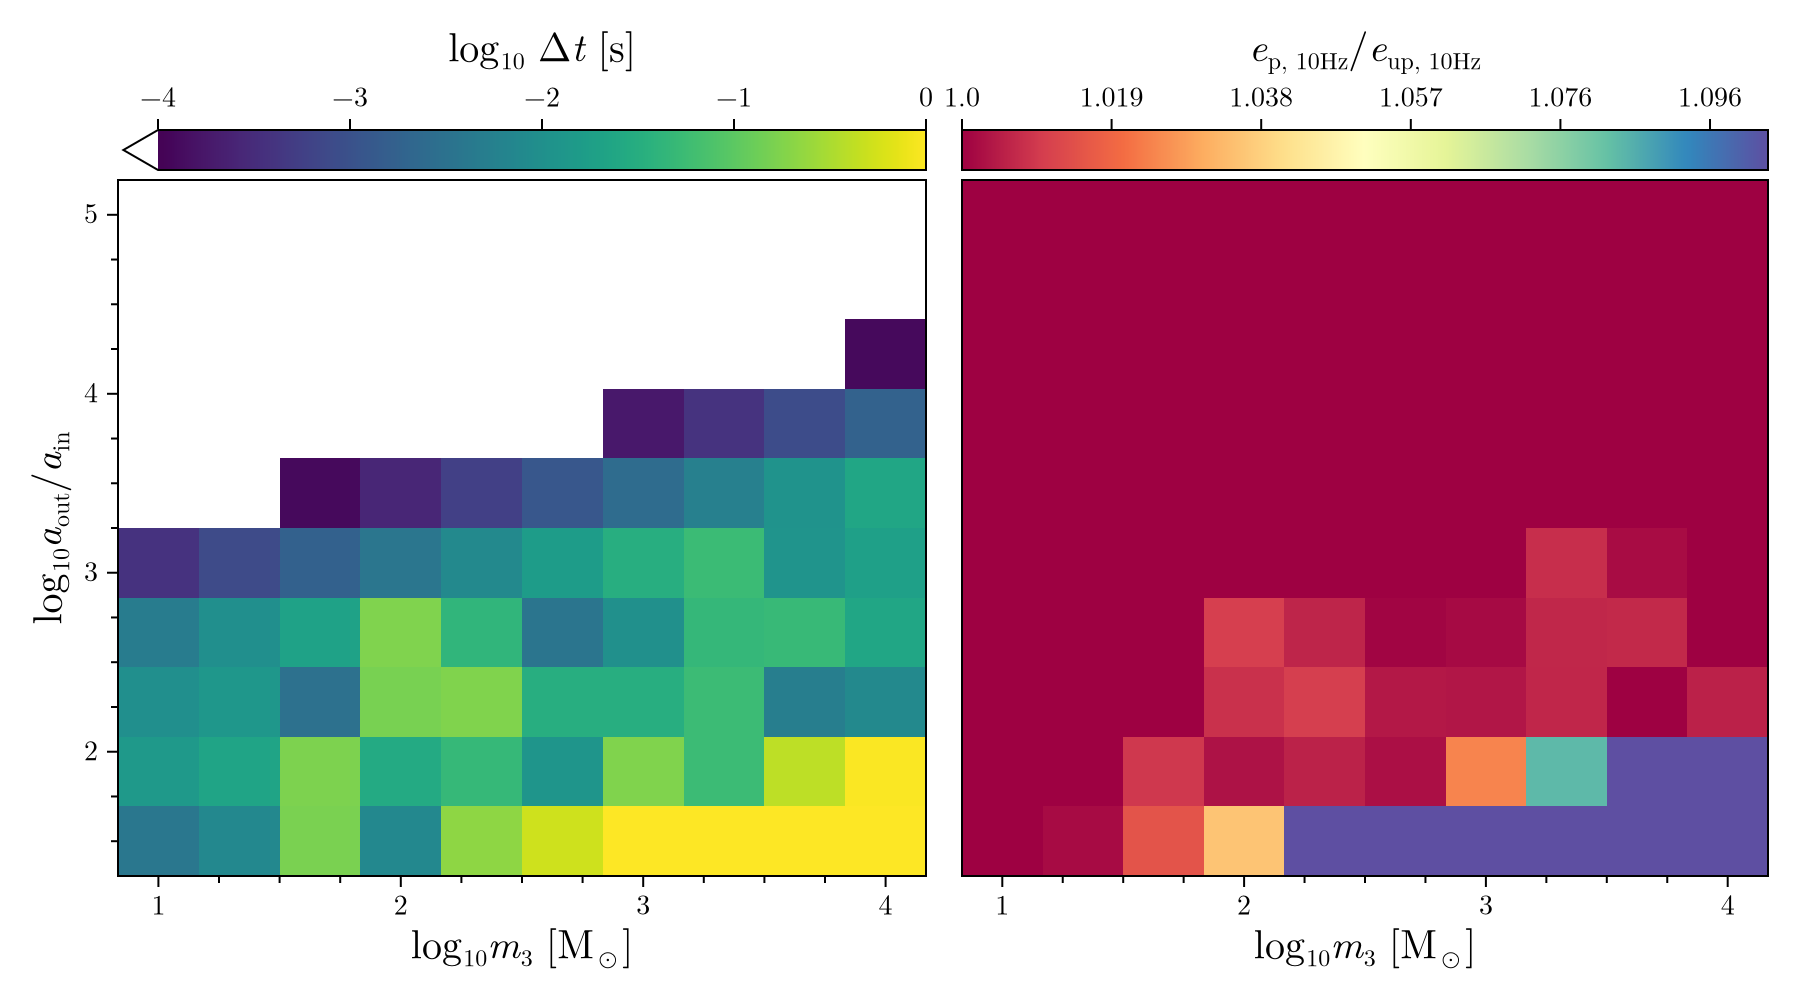

In [ ]:
let 
    local fig
    if true
        for eta in (0.2,)# 0.24)
            for i in (100,)# 100)
                fig = Figure(size=(900, 500))
                ax_dt = Axis(fig[1, 1], ylabel=L"\log_{10}{a_\text{out}/a_\text{in}}", 
                                      xlabel=L"$\log_{10}{m_3}$ [M$_\odot$]")
                ax_e = Axis(fig[1, 2],  xlabel=L"$\log_{10}{m_3}$ [M$_\odot$]")
                hideydecorations!(ax_e)

                log10_m3s, log10_alphas, dt_max, e_10Hzs = do_parameter_study(n_m3s=10, n_alphas=10, 
                                                                              log10_m3_min=1, log10_m3_max=4, 
                                                                              log10_alpha_min=1.5, log10_alpha_max=5, 
                                                                              eta=eta, i0=deg2rad(i))
                hm_dt = heatmap!(ax_dt, log10_m3s, log10_alphas, log10.(dt_max), colorrange=(-4, 0), lowclip=:white)
                e = log10.(e_10Hzs)
                e_mean = sum(e)/length(e)
                hm_e = heatmap!(ax_e, log10_m3s, log10_alphas, e, colorrange=(0.0, e_mean), colormap=Makie.to_colormap(:Spectral))
                Colorbar(fig[0, 1], hm_dt, vertical=false, label=L"log$_{10}$ $\Delta t$ [s]", labelsize=20, height=20)
                Colorbar(fig[0, 2], hm_e, vertical=false, label=L"$e_\text{p, 10Hz}/e_\text{up, 10Hz}$", labelsize=20, 
                                    ticks=LinearTicks(7), tickformat = values -> ["$(round(10^v, digits=3))" for v in values], height=20)
                rowgap!(fig.layout, 1, 5.0)
            end
        end
    end
    fig
end

# Zoomed-in, with outer eccentricity

### All

In [140]:
let 
    format = values -> ["$(round(Int, 10^v))" for v in values]
    # local fig
    if true
        for e_out in (0.0, 0.4, 0.7)
            for i in (0, 100)
                fig = Figure(size=(900, 500))
                ax_dt = Axis(fig[1, 1], ylabel=L"a_\text{out}/a_\text{in}", 
                                      xlabel=L"$m_3$ [M$_\odot$]", xtickformat=format, ytickformat=format, xticks=LinearTicks(7))
                ax_e = Axis(fig[1, 2],  xlabel=L"$m_3$ [M$_\odot$]", xtickformat=format, xticks=LinearTicks(7))
                hideydecorations!(ax_e)

                log10_m3s, log10_alphas, dt_max, e_10Hzs = do_parameter_study(n_m3s=250, n_alphas=250, 
                                                                              log10_m3_min=1, log10_m3_max=1.7, 
                                                                              log10_alpha_min=1, log10_alpha_max=2.5, 
                                                                              e3=e_out, i0=deg2rad(i))
                hm_dt = heatmap!(ax_dt, log10_m3s, log10_alphas, log10.(dt_max), colorrange=(-4, 0), lowclip=:white)
                e = log10.(e_10Hzs)
                e_mean = sum(e)/length(e)
                hm_e = heatmap!(ax_e, log10_m3s, log10_alphas, e, colorrange=(0.0, e_mean), colormap=reverse(Makie.to_colormap(:matter)))
                Colorbar(fig[0, 1], hm_dt, vertical=false, label=L"log$_{10}$ $\Delta t$ [s]", labelsize=20)
                Colorbar(fig[0, 2], hm_e, vertical=false, label=L"$e_\text{p, 10Hz}/e_\text{up, 10Hz}$", labelsize=20, 
                                    ticks=LinearTicks(7), tickformat = values -> ["$(round(10^v, digits=3))" for v in values])
                rowgap!(fig.layout, 1, 5.0)
                Makie.save(joinpath(@__DIR__, "..", "figures", "parameter-map-zoom-e3_$(e_out)_i_$(i).png"), fig)
            end
        end
    end
    # fig
end

ArgumentError: ArgumentError: reducing over an empty collection is not allowed; consider supplying `init` to the reducer

### One

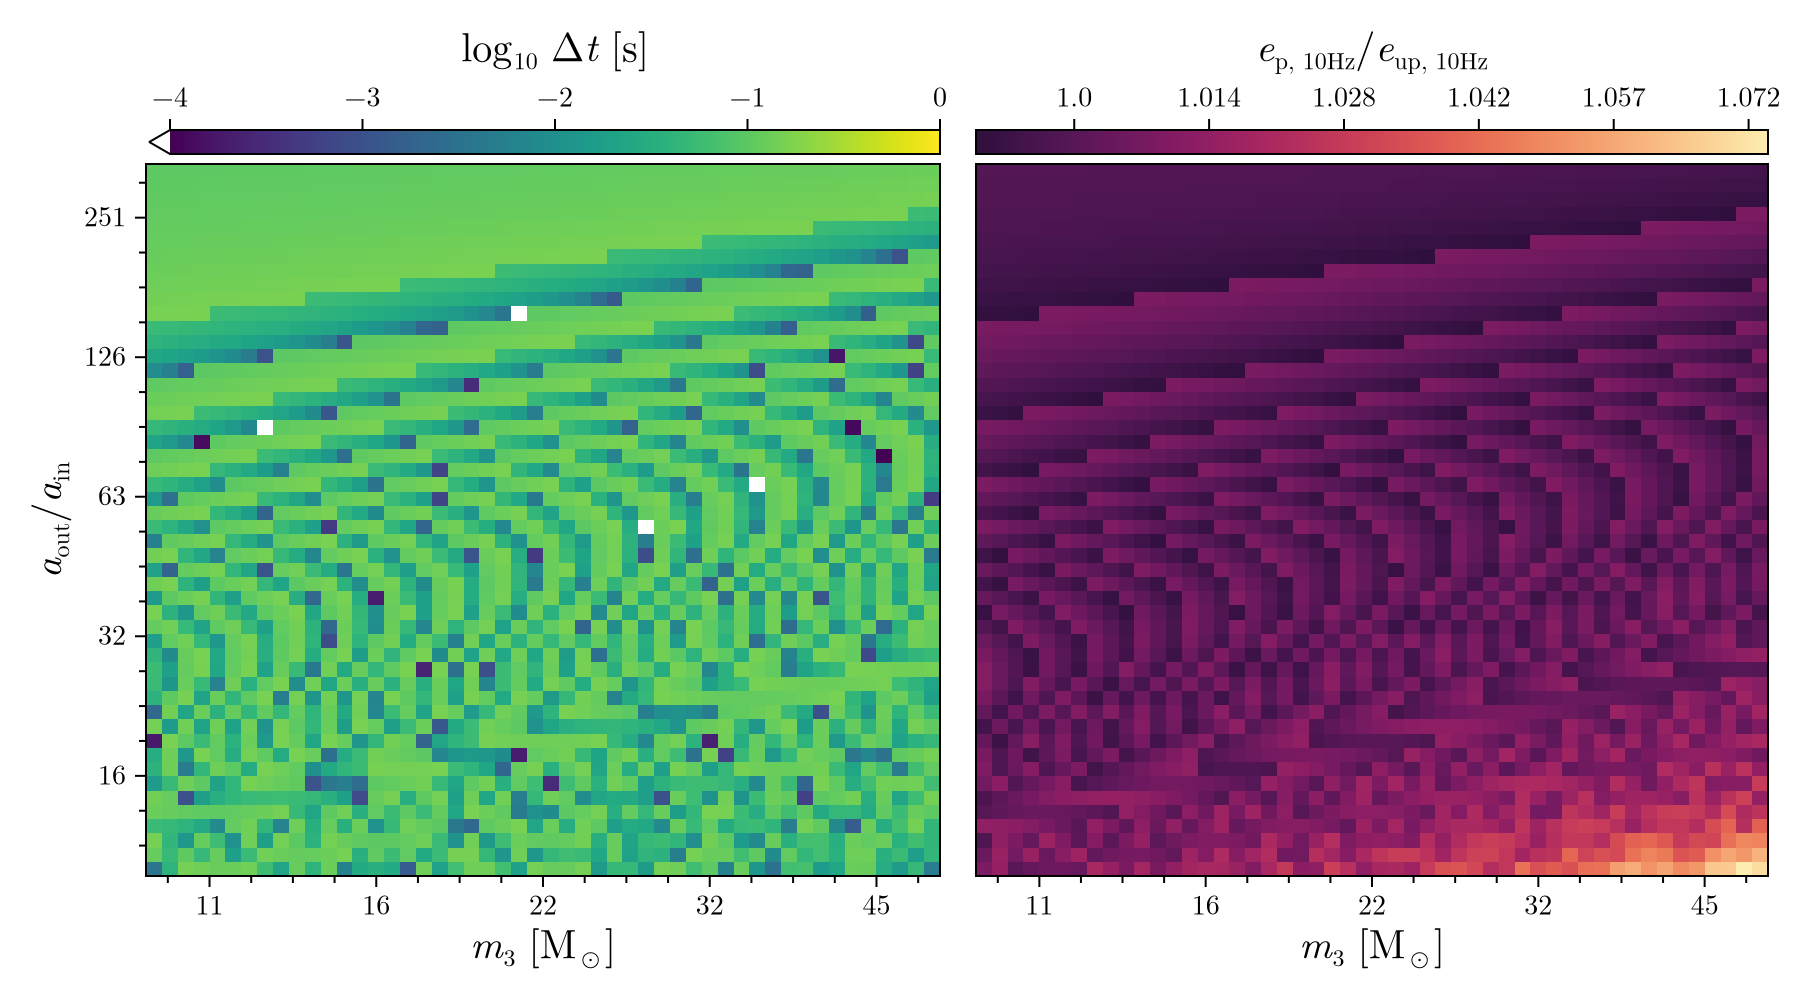

In [135]:
let 
    format = values -> ["$(round(Int, 10^v))" for v in values]
    local fig
    if true
        for e_out in (0.7,)# 0.4, 0.7)
            for i in (100,)# 100)
                fig = Figure(size=(900, 500))
                ax_dt = Axis(fig[1, 1], ylabel=L"a_\text{out}/a_\text{in}", 
                                      xlabel=L"$m_3$ [M$_\odot$]", xtickformat=format, ytickformat=format, xticks=LinearTicks(7))
                ax_e = Axis(fig[1, 2],  xlabel=L"$m_3$ [M$_\odot$]", xtickformat=format, xticks=LinearTicks(7))
                hideydecorations!(ax_e)

                log10_m3s, log10_alphas, dt_max, e_10Hzs = do_parameter_study(n_m3s=50, n_alphas=50, 
                                                                              log10_m3_min=1, log10_m3_max=1.7, 
                                                                              log10_alpha_min=1, log10_alpha_max=2.5, 
                                                                              e3=e_out, i0=deg2rad(i), V3=0.0)
                hm_dt = heatmap!(ax_dt, log10_m3s, log10_alphas, log10.(dt_max), colorrange=(-4, 0), lowclip=:white)
                e = log10.(e_10Hzs)
                e_mean = sum(e)/length(e)
                hm_e = heatmap!(ax_e, log10_m3s, log10_alphas, e, colormap=reverse(Makie.to_colormap(:matter)))
                Colorbar(fig[0, 1], hm_dt, vertical=false, label=L"log$_{10}$ $\Delta t$ [s]", labelsize=20)
                Colorbar(fig[0, 2], hm_e, vertical=false, label=L"$e_\text{p, 10Hz}/e_\text{up, 10Hz}$", labelsize=20, 
                                    ticks=LinearTicks(7), tickformat = values -> ["$(round(10^v, digits=3))" for v in values])
                rowgap!(fig.layout, 1, 5.0)
                # Makie.save(joinpath(@__DIR__, "..", "figures", "parameter-map2-zoom-e3_$(e_out)_i_$(i).png"), fig)
            end
        end
    end
    fig
end

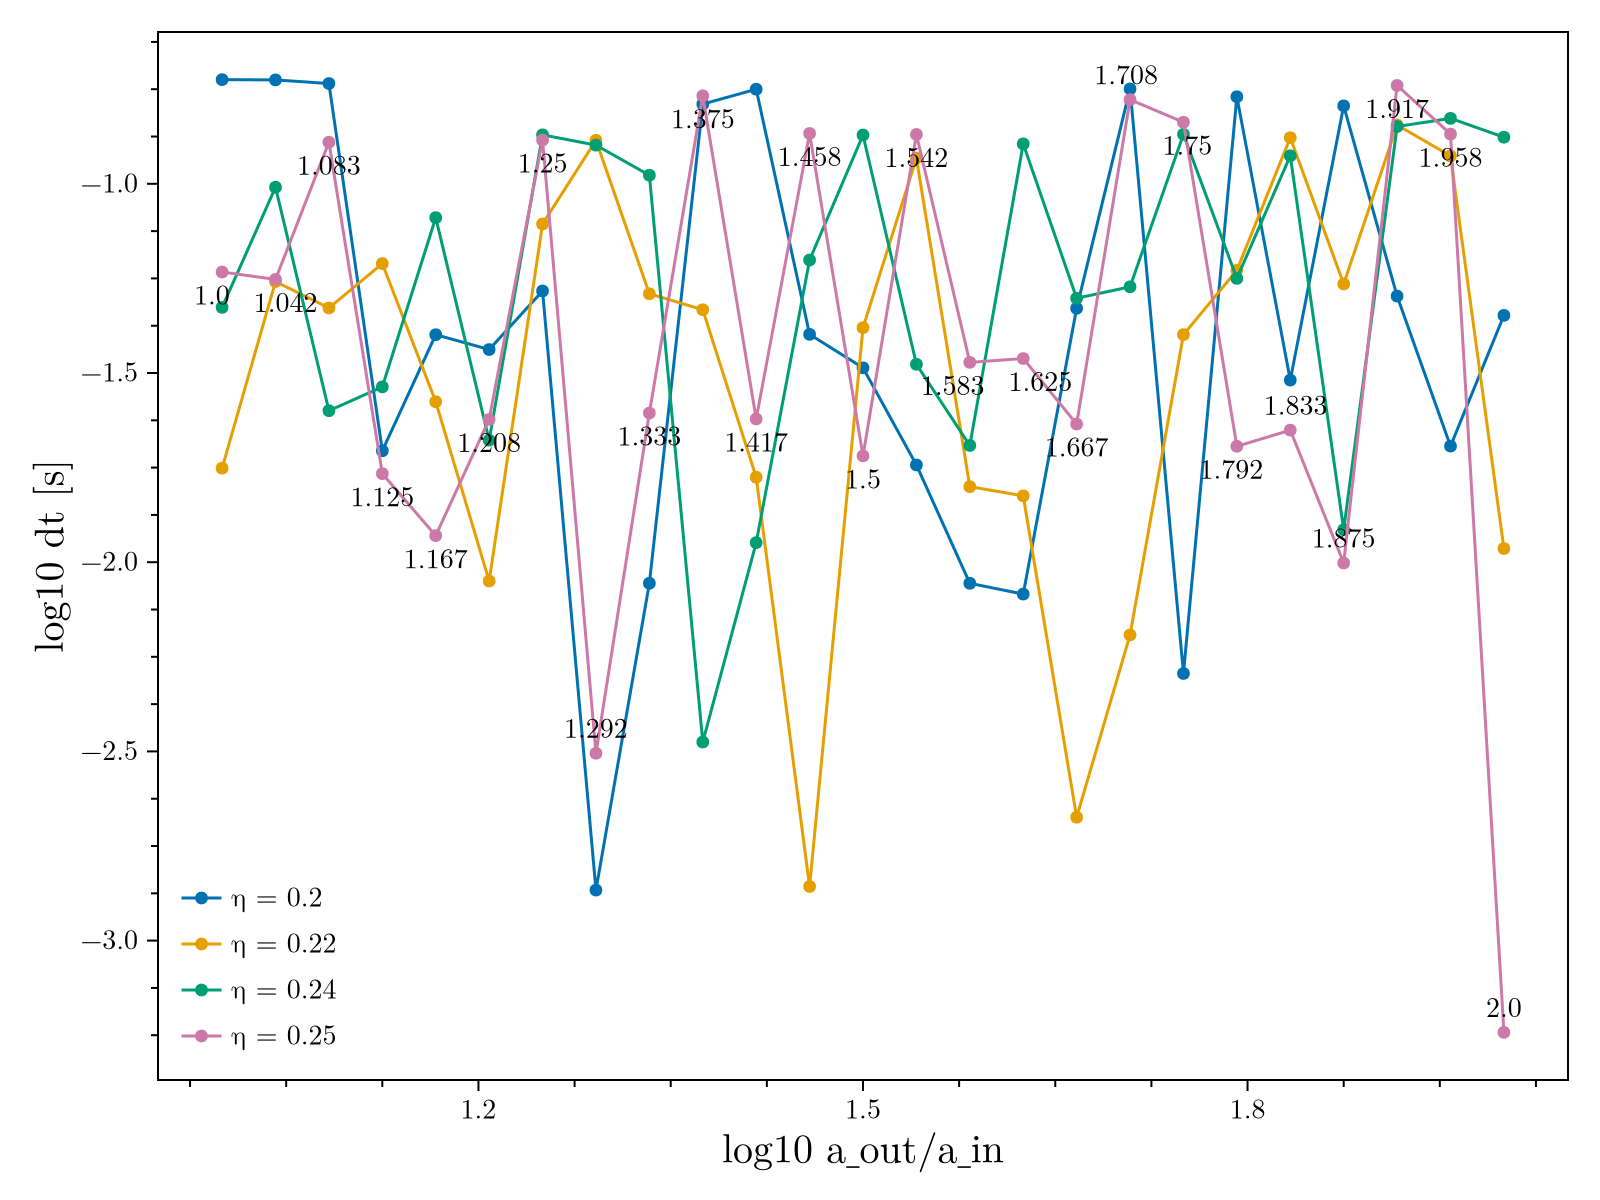

In [82]:
let
    fig = Figure()
    ax = Axis(fig[1, 1], xlabel="log10 a_out/a_in", ylabel="log10 dt [s]")

    
    for eta in (0.2, 0.22, 0.24, 0.25)
        log10_m3s, log10_alphas, dt_max, _ = do_parameter_study(n_m3s=2, n_alphas=25, 
                                                                log10_m3_min=1, log10_m3_max=2, 
                                                                log10_alpha_min=1, log10_alpha_max=2, 
                                                                eta=eta)
        scatterlines!(ax, log10_alphas, log10.(dt_max[2,:]), label="η = $eta")
        if eta ≈ 0.25
            annotation!(ax, log10_alphas, log10.(dt_max[2,:]), text=string.(round.(log10_alphas, digits=3)))
        end
    end
    
    # hm = heatmap!(log10_m3s, log10_alphas, log10.(dt_max))
    # Colorbar(fig[1, 2], hm, label="max Δt [s]", labelsize=20)
    axislegend(ax, position=:lb)
    fig
end

In [84]:
3/2

1.5

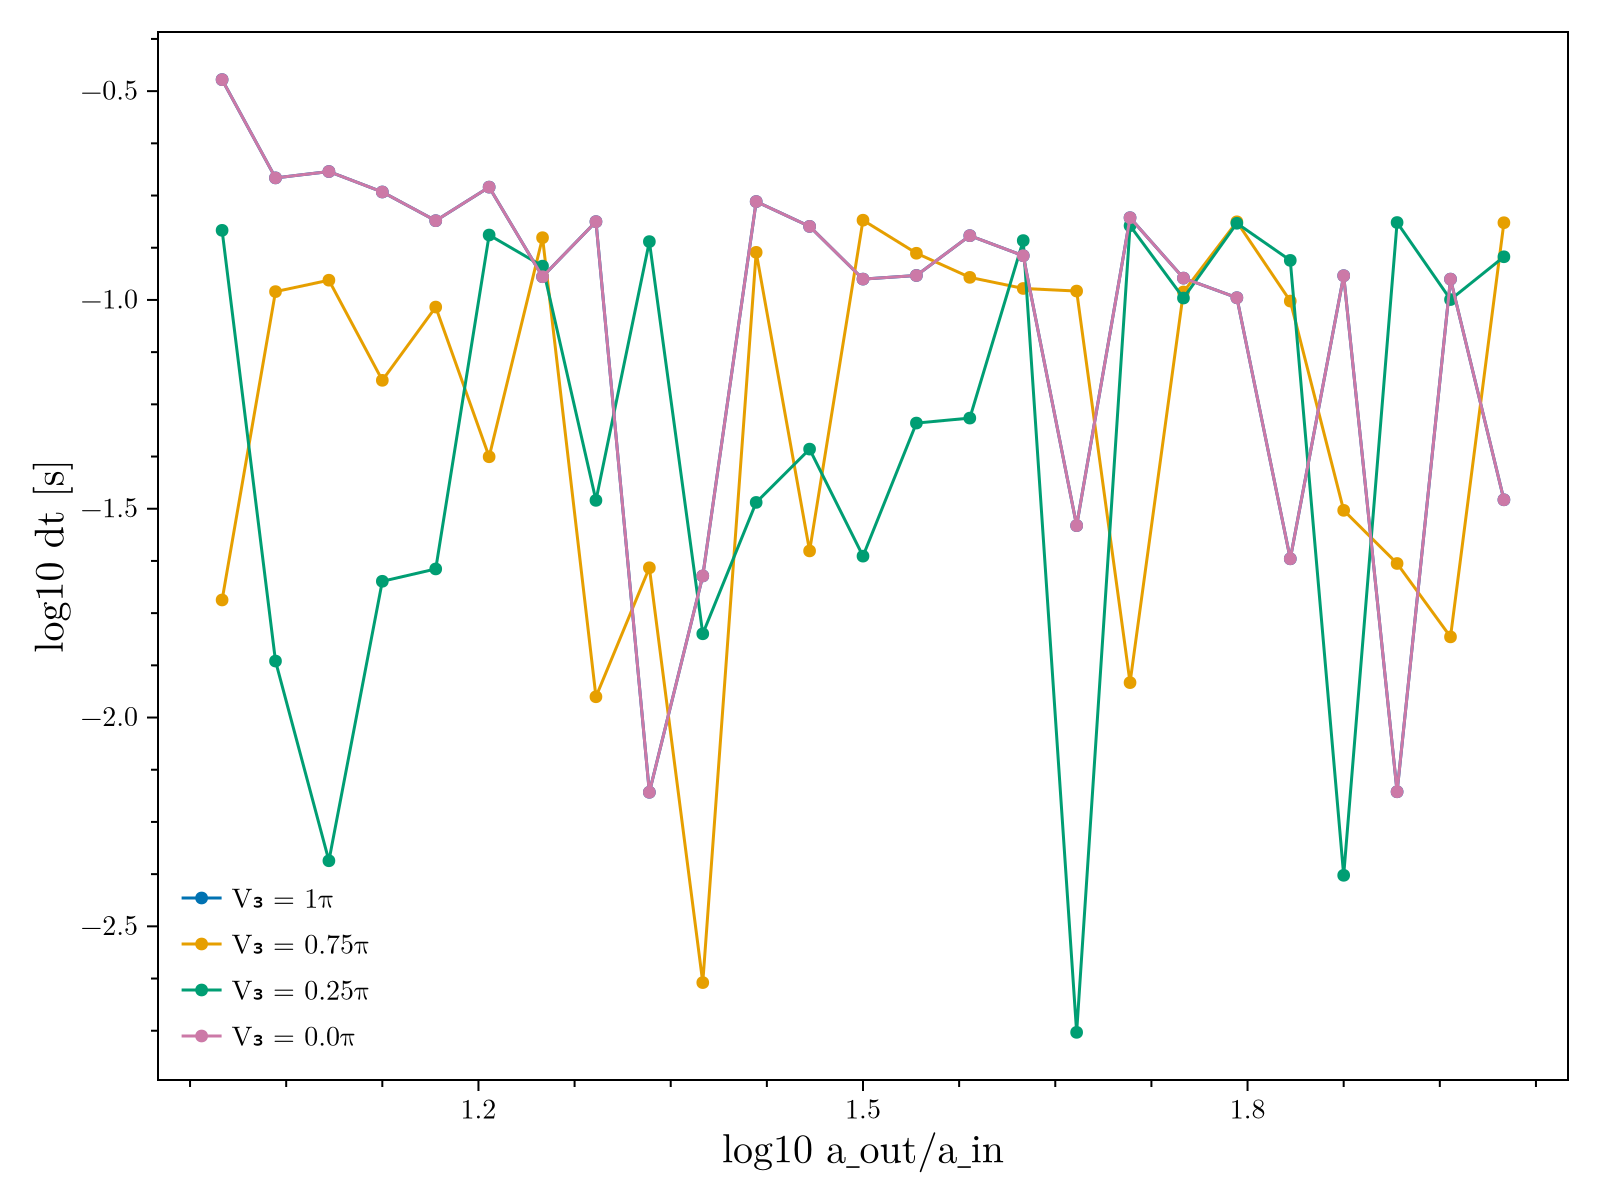

In [86]:
let
    fig = Figure()
    ax = Axis(fig[1, 1], xlabel="log10 a_out/a_in", ylabel="log10 dt [s]")

    
    for V3 in (1, 3/4, 1/4, 0.0) 
        log10_m3s, log10_alphas, dt_max, _ = do_parameter_study(n_m3s=2, n_alphas=25, 
                                                                log10_m3_min=1, log10_m3_max=2, 
                                                                log10_alpha_min=1, log10_alpha_max=2, V3=V3*π)
        scatterlines!(ax, log10_alphas, log10.(dt_max[2,:]), label="V₃ = $(V3)π")
        # if eta ≈ 0.25
        #     annotation!(ax, log10_alphas, log10.(dt_max[2,:]), text=string.(round.(log10_alphas, digits=3)))
        # end
    end
    
    # hm = heatmap!(log10_m3s, log10_alphas, log10.(dt_max))
    # Colorbar(fig[1, 2], hm, label="max Δt [s]", labelsize=20)
    axislegend(ax, position=:lb)
    fig
end

# N-body

In [87]:
using Syzygy, Peaks
using LinearAlgebra: norm

In [88]:
function do_parameter_study_nbody(;n_m3s=15, n_alphas=15, log10_m3_min=1, log10_m3_max=2, log10_alpha_min=1, log10_alpha_max=5,
    m12=80Msun, eta=0.24, a_in=0.1Rsun, e_in=0.9, i0=0.0, e_out=0.0, N_bursts=5, fac=1, params...)
  
    m1, m2 = EBT.get_masses(m12, eta)

    log10_m3s = range(log10_m3_min, log10_m3_max, length=n_m3s)
    log10_alphas = range(log10_alpha_min, log10_alpha_max, length=n_alphas)

    solver_options = Dict(:alg => Syzygy.ODESolvers.FineRKN5, 
                          :abstol => 1e-12, :reltol => 1e-12, 
                          :max_cpu_time => 2)
                          
    dt_max = zeros(Float64, n_m3s, n_alphas)
    e_10Hzs = similar(dt_max)
    
    m_up = multibodysystem([m1, m2], a=a_in, e=e_in)
    T = N_bursts*m_up.binaries[1].elements.P
    Threads.@threads for i ∈ eachindex(log10_m3s)
        m3 = (10^log10_m3s[i])*Msun

        for j ∈ eachindex(log10_alphas)
            a_out = (10^log10_alphas[j])*a_in*fac
        
            t_up = let m = m_up
                pot = [PureGravitationalPotential(m), PN2p5Potential(m)]
                res = simulate(m, t_sim=T, potential=pot, callbacks=[];
                                solver_options...)
                
                sol = postprocess(res)
                d = norm.(eachcol(sol.r[particle=1] .- sol.r[particle=2]))

                ids, _ = findminima(d)
                sol.t[ids]
            end

            m_p = multibodysystem([m1, m2, m3], a=[a_in, a_out], e=[e_in, e_out], i=[i0, 0.0])
            t_p = let m = m_p
                pot = [PureGravitationalPotential(m), PN2p5Potential(m)]
                res = simulate(m, t_sim=T, potential=pot, callbacks=[];
                                solver_options...)
                sol = postprocess(res)
                d = norm.(eachcol(sol.r[particle=1] .- sol.r[particle=2]))

                ids, _ = findminima(d)
                sol.t[ids]
            end

            k = min(length(t_up), length(t_p))

            Δt = t_p[end] - t_up[end]
            t_up .+= Δt

            dt = abs(t_up[k-1] - t_p[k-1])

            dt_max[i, j] = ustrip(u"s", dt)
        end
        
    end

    
    # heatmap(log10_m3s, log10_alphas, dt_max)
    return log10_m3s, log10_alphas, dt_max
end

do_parameter_study_nbody (generic function with 1 method)

In [111]:
let
    m12 = 80
    eta = 0.24
    e0 = 0.9
    m3 = 100
    a0 = get_a_at_xHz(1, e0, m12)
    R3 = 1000*a0

    m = BurstTimingModel(m12=m12, eta=eta, e0=e0, a0=a0, m3=m3)
    println(EBT.peak_f_GW(m, 1))

    evolve!(m, 2_000_000, Rmin_threshold=Inf, e_min=0.0001, f_GW_max=10, verbose=true)
    println(m.status == :fGW)
    n = length(m.t)
    @show n
    println("a_in: ", EBT.get_a(m, n)/EBT.Rsun_to_m, " R⊙")#/EBT.get_a(m, n))
    println("fac: ", EBT.get_a(m, 1)/EBT.get_a(m, n))
    println(println("e_in: ", EBT.get_e(m, n)))
end;

1.002392085511042


┌ Info: Stopping condition: fGW > fGW_max
└ @ EccentricBurstTiming /home/cwbruenech/projects/EccentricBurstTimings/src/EccentricBurstTiming.jl/src/EccentricBurstTiming.jl:218


true
n = 3897
a_in: 0.0032580780625256585 R⊙
fac: 39.67380953099584
e_in: 0.04320847822285886
nothing


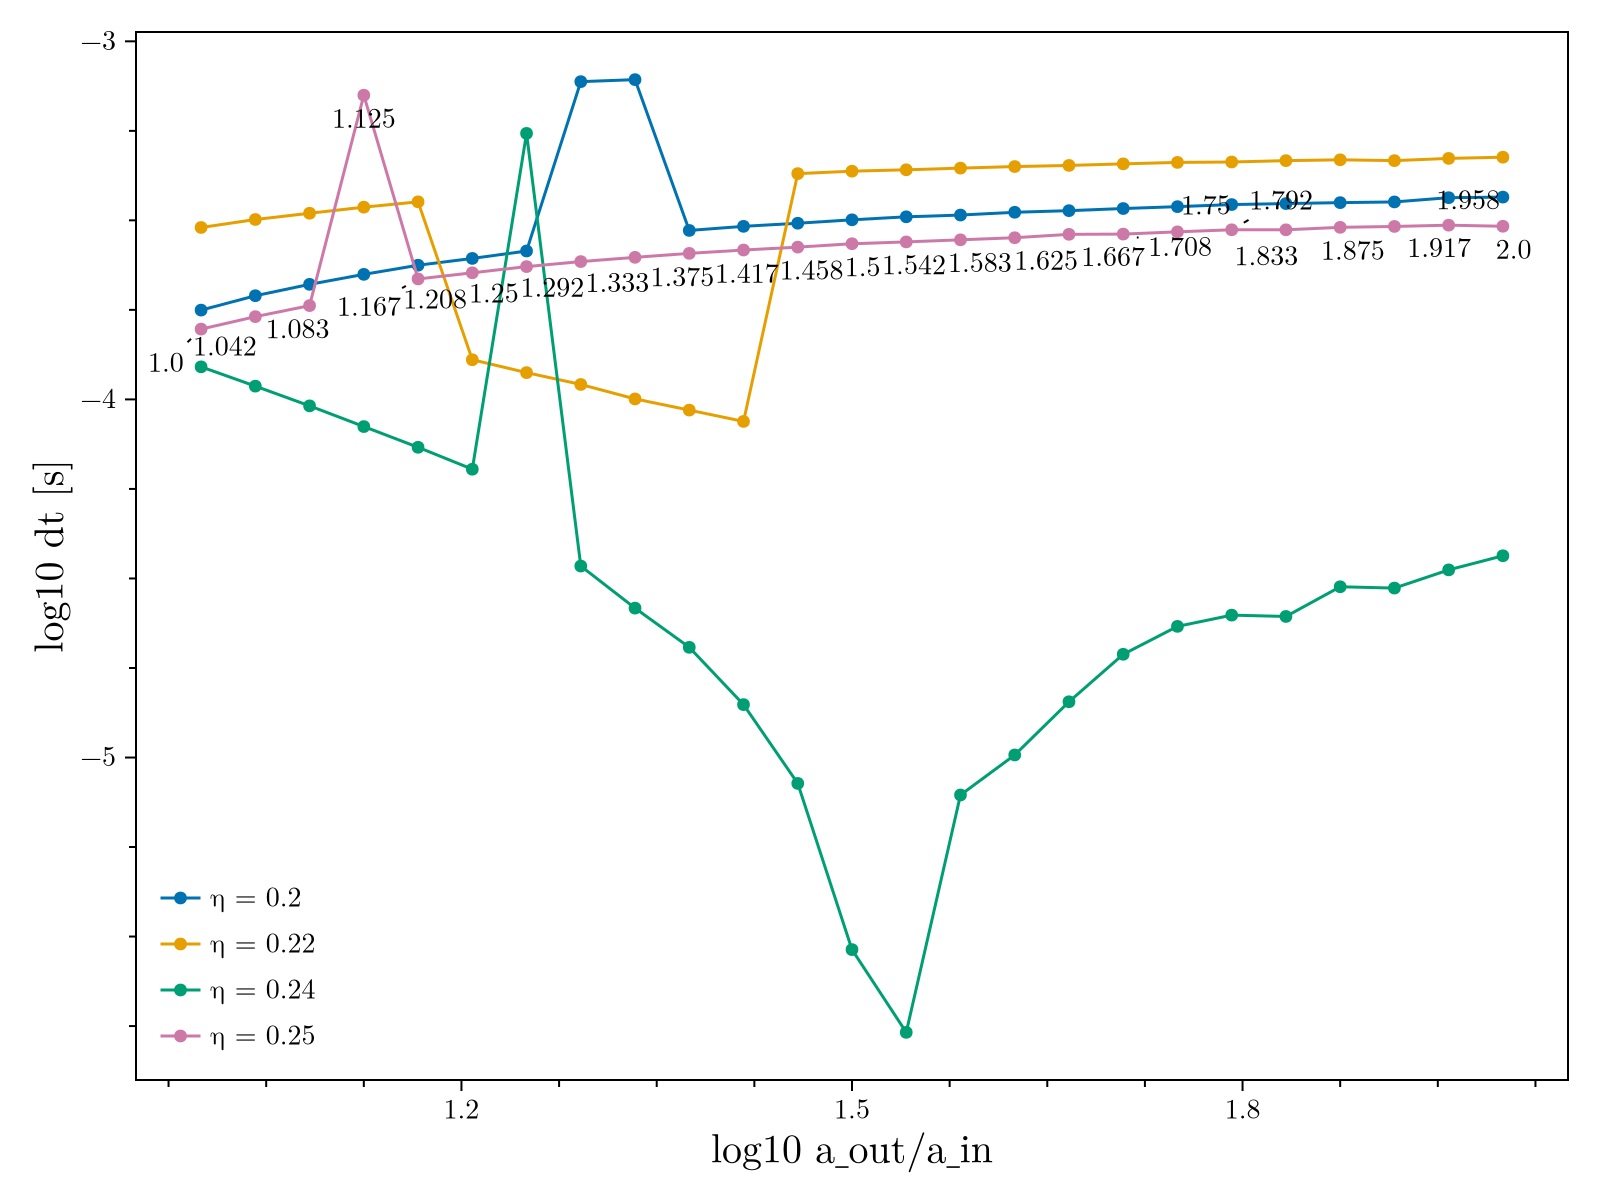

In [106]:
let
    fig = Figure()
    ax = Axis(fig[1, 1], xlabel="log10 a_out/a_in", ylabel="log10 dt [s]")

    
    for eta in (0.2, 0.22, 0.24, 0.25)
        log10_m3s, log10_alphas, dt_max = do_parameter_study_nbody(n_m3s=2, n_alphas=25, a_in=0.003Rsun, e_in=0.04,
                                                                log10_m3_min=1, log10_m3_max=2, 
                                                                log10_alpha_min=1, log10_alpha_max=2, 
                                                                eta=eta, fac=39)
        scatterlines!(ax, log10_alphas, log10.(dt_max[2,:]), label="η = $eta")
        if eta ≈ 0.25
            annotation!(ax, log10_alphas, log10.(dt_max[2,:]), text=string.(round.(log10_alphas, digits=3)))
        end
    end
    
    # hm = heatmap!(log10_m3s, log10_alphas, log10.(dt_max))
    # Colorbar(fig[1, 2], hm, label="max Δt [s]", labelsize=20)
    axislegend(ax, position=:lb)
    fig
end

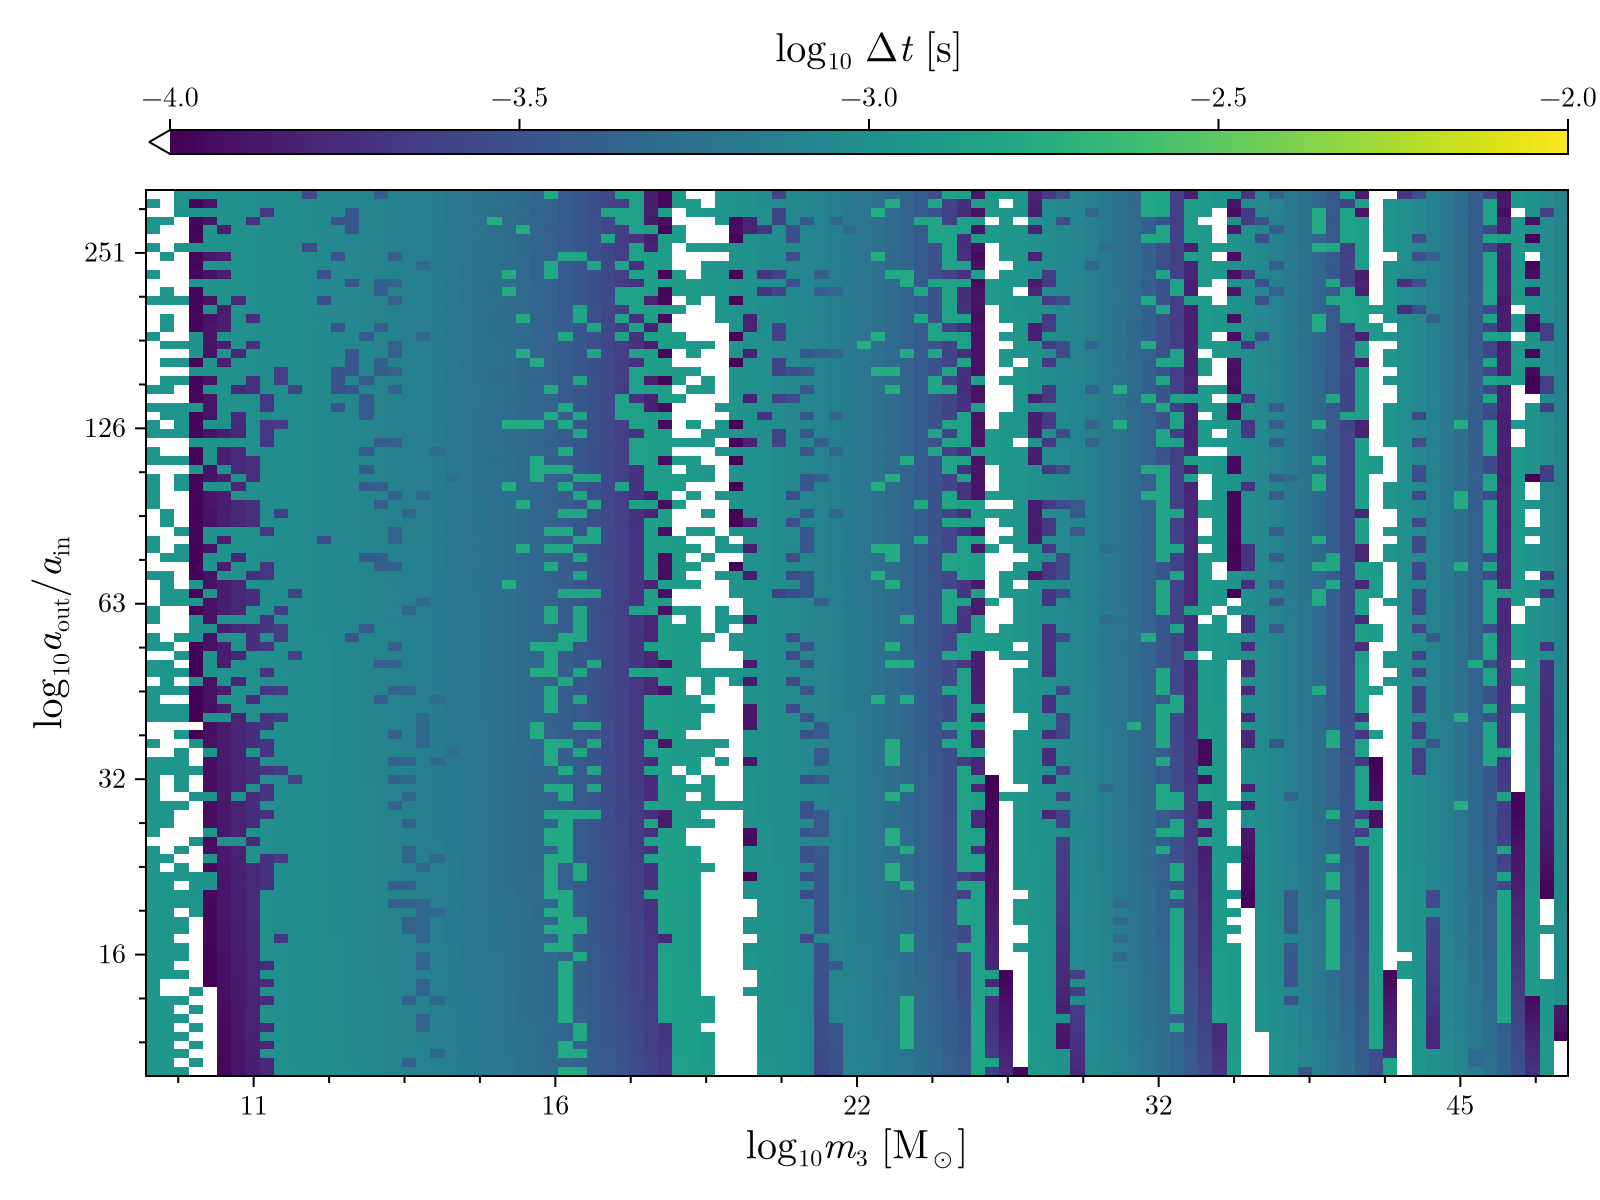

In [109]:
let 
    format = values -> ["$(round(Int, 10^v))" for v in values]
    local fig
    if true
        for e_out in (0.0,)# 0.4, 0.7)
            for i in (0,)# 100)
                fig = Figure()
                ax_dt = Axis(fig[1, 1], ylabel=L"\log_{10}{a_\text{out}/a_\text{in}}", 
                                      xlabel=L"$\log_{10}{m_3}$ [M$_\odot$]", xtickformat=format, ytickformat=format, xticks=LinearTicks(7))
                # ax_e = Axis(fig[1, 2],  xlabel=L"$\log_{10}{m_3}$ [M$_\odot$]", xtickformat=format, xticks=LinearTicks(7))
                # hideydecorations!(ax_e)

                log10_m3s, log10_alphas, dt_max = do_parameter_study_nbody(n_m3s=100, n_alphas=100,a_in=0.005Rsun, e_in=0.05, 
                                                                              log10_m3_min=1, log10_m3_max=1.7, 
                                                                              log10_alpha_min=1, log10_alpha_max=2.5, 
                                                                              e3=e_out, i0=deg2rad(i), fac=39)
                hm_dt = heatmap!(ax_dt, log10_m3s, log10_alphas, log10.(dt_max), colorrange=(-4, -2), lowclip=:white)
                # hm_e = heatmap!(ax_e, log10_m3s, log10_alphas, e_10Hzs, colorrange=(1.001, 5), lowclip=:white)
                Colorbar(fig[0, 1], hm_dt, vertical=false, label=L"log$_{10}$ $\Delta t$ [s]", labelsize=20)
                # Colorbar(fig[0, 2], hm_e, vertical=false, label=L"$e_\text{p, 10Hz}/e_\text{up, 10Hz}$", labelsize=20)
                # Makie.save(joinpath(@__DIR__, "..", "figures", "parameter-map-nbody-zoom-e3_$(e_out)_i_$(i).png"), fig)
            end
        end
    end
    fig
end

# At lower frequencies

In [162]:
let
    m12 = 80
    eta = 0.24
    e0 = 0.99
    m3 = 0.0#100
    a0 = get_a_at_xHz(0.001, e0, m12)
    R3 = 1000*a0

    m = BurstTimingModel(m12=m12, eta=eta, e0=e0, a0=a0, m3=m3)
    println(EBT.peak_f_GW(m, 1))

    evolve!(m, 2_000_000, Rmin_threshold=Inf, e_min=0.0001, f_GW_max=0.001+1e-5, verbose=true)
    println(m.status == :fGW)
    n = length(m.t)
    @show n
    println("a_in: ", EBT.get_a(m, n)/EBT.Rsun_to_m, " R⊙")#/EBT.get_a(m, n))
    println("fac: ", EBT.get_a(m, 1)/EBT.get_a(m, n))
    println(println("e_in: ", EBT.get_e(m, n)))
end;

0.0010023920855110424
false
n = 2000002
a_in: 97.72972283821052 R⊙
fac: 1.310242942822286
e_in: 0.9869117432378652
nothing


## LISA

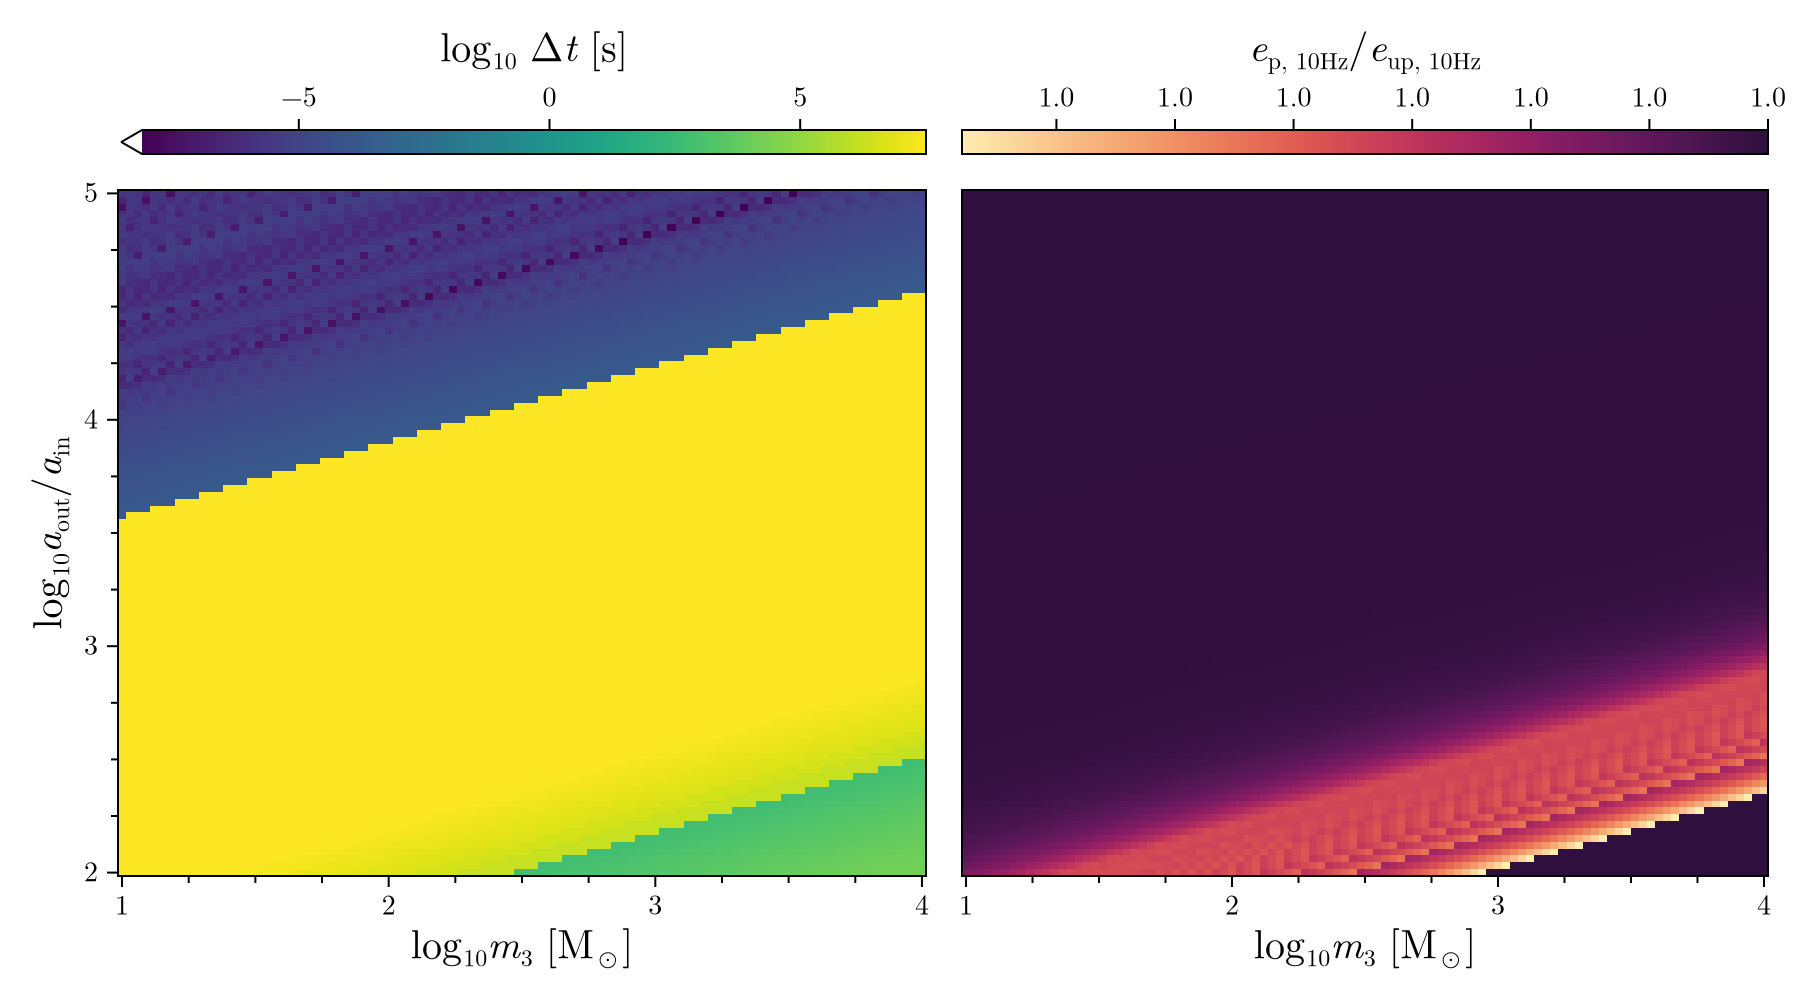

In [171]:
let 
    local fig
    if true
        for eta in (0.24,)# 0.24)
            for i in (0,)# 100)
                fig = Figure(size=(900, 500))
                ax_dt = Axis(fig[1, 1], ylabel=L"\log_{10}{a_\text{out}/a_\text{in}}", 
                                      xlabel=L"$\log_{10}{m_3}$ [M$_\odot$]")
                ax_e = Axis(fig[1, 2],  xlabel=L"$\log_{10}{m_3}$ [M$_\odot$]")
                hideydecorations!(ax_e)

                log10_m3s, log10_alphas, dt_max, e_10Hzs = do_parameter_study(n_m3s=100, n_alphas=100, 
                                                                              log10_m3_min=1, log10_m3_max=4, 
                                                                              log10_alpha_min=2, log10_alpha_max=5, 
                                                                              eta=eta, i0=deg2rad(i), f0=0.001, f_match=0.001,
                                                                              e_in=0.99, N_bursts=20, force=true)
                hm_dt = heatmap!(ax_dt, log10_m3s, log10_alphas, log10.(dt_max), lowclip=:white)
                e = log10.(e_10Hzs)
                e_mean = sum(e)/length(e)
                hm_e = heatmap!(ax_e, log10_m3s, log10_alphas, e, colormap=Makie.to_colormap(:matter))
                Colorbar(fig[0, 1], hm_dt, vertical=false, label=L"log$_{10}$ $\Delta t$ [s]", labelsize=20)
                Colorbar(fig[0, 2], hm_e, vertical=false, label=L"$e_\text{p, 10Hz}/e_\text{up, 10Hz}$", labelsize=20, 
                                    ticks=LinearTicks(7), tickformat = values -> ["$(round(10^v, digits=3))" for v in values])
                # Makie.save(joinpath(@__DIR__, "..", "figures", "parameter-map-eta_$(eta)_i_$(i).png"), fig)
            end
        end
    end
    fig
end

## ET

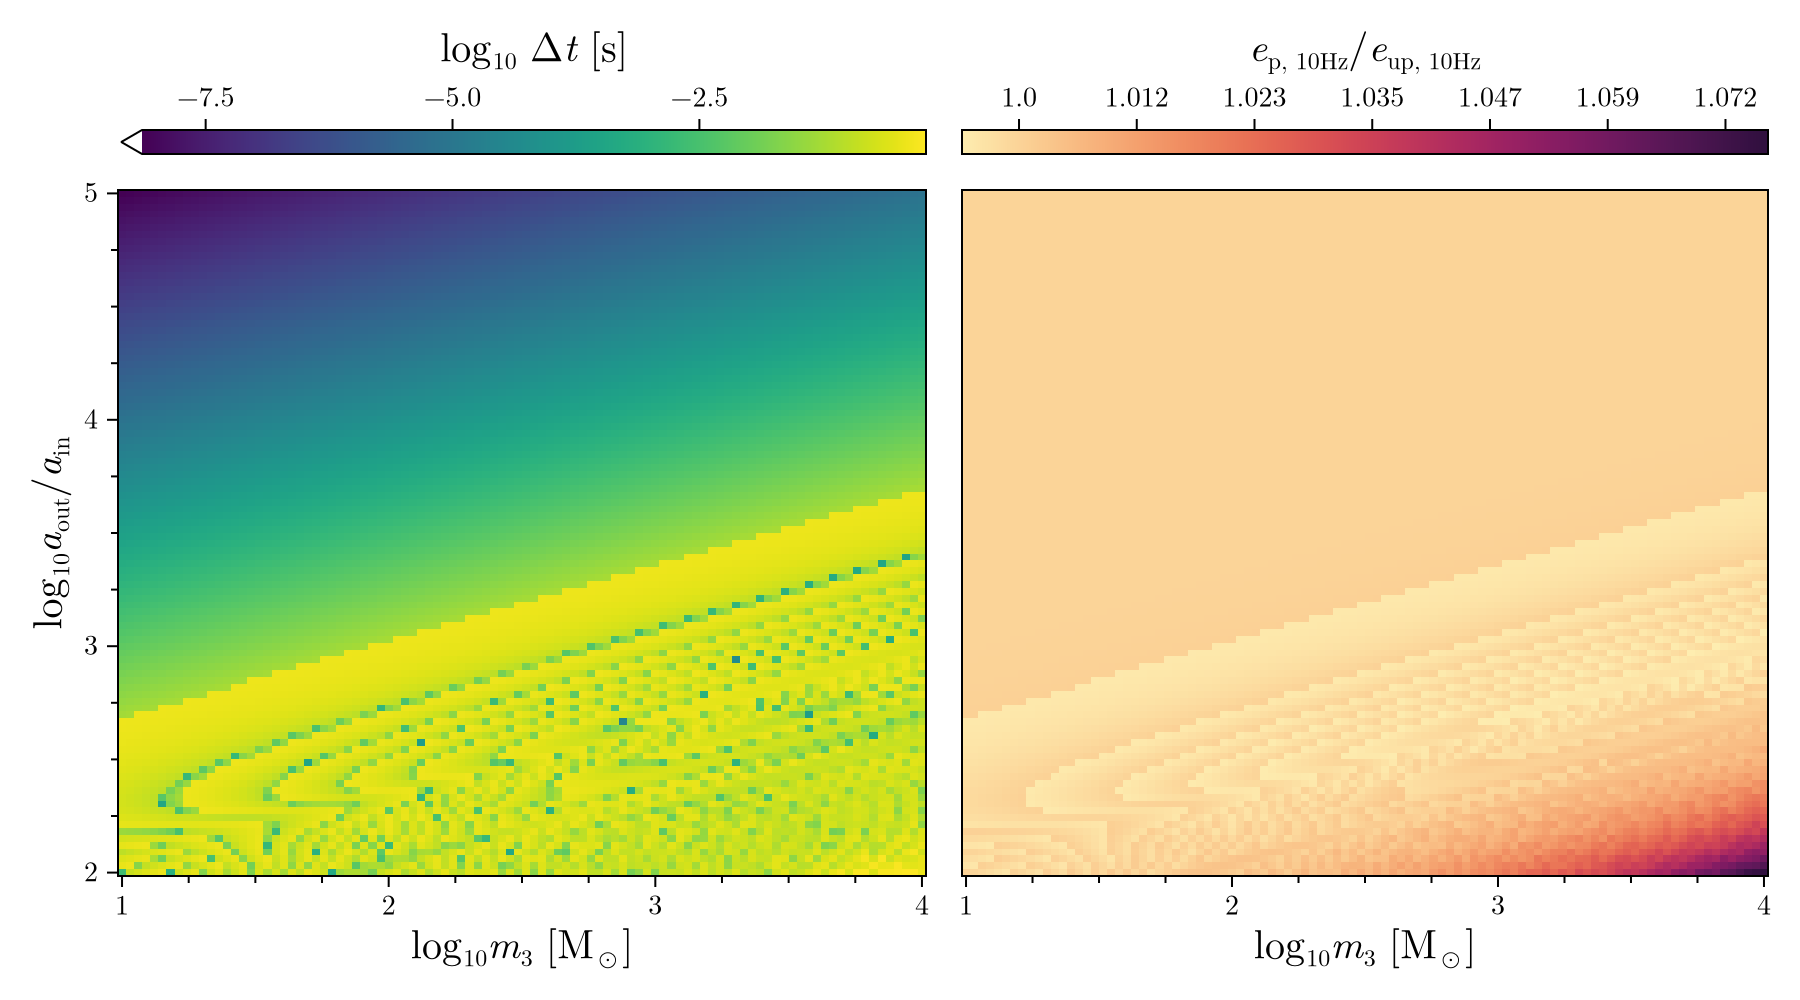

In [149]:
let 
    local fig
    if true
        for eta in (0.24,)# 0.24)
            for i in (0,)# 100)
                fig = Figure(size=(900, 500))
                ax_dt = Axis(fig[1, 1], ylabel=L"\log_{10}{a_\text{out}/a_\text{in}}", 
                                      xlabel=L"$\log_{10}{m_3}$ [M$_\odot$]")
                ax_e = Axis(fig[1, 2],  xlabel=L"$\log_{10}{m_3}$ [M$_\odot$]")
                hideydecorations!(ax_e)

                log10_m3s, log10_alphas, dt_max, e_10Hzs = do_parameter_study(n_m3s=100, n_alphas=100, 
                                                                              log10_m3_min=1, log10_m3_max=4, 
                                                                              log10_alpha_min=2, log10_alpha_max=5, 
                                                                              eta=eta, i0=deg2rad(i), f0=1, f_match=5,
                                                                              e_in=0.9, N_bursts=2_000_000)
                hm_dt = heatmap!(ax_dt, log10_m3s, log10_alphas, log10.(dt_max), lowclip=:white)
                e = log10.(e_10Hzs)
                e_mean = sum(e)/length(e)
                hm_e = heatmap!(ax_e, log10_m3s, log10_alphas, e, colormap=Makie.to_colormap(:matter))
                Colorbar(fig[0, 1], hm_dt, vertical=false, label=L"log$_{10}$ $\Delta t$ [s]", labelsize=20)
                Colorbar(fig[0, 2], hm_e, vertical=false, label=L"$e_\text{p, 10Hz}/e_\text{up, 10Hz}$", labelsize=20, 
                                    ticks=LinearTicks(7), tickformat = values -> ["$(round(10^v, digits=3))" for v in values])
                # Makie.save(joinpath(@__DIR__, "..", "figures", "parameter-map-eta_$(eta)_i_$(i).png"), fig)
            end
        end
    end
    fig
end